# 04 — Video Frame Cache

Builds the per-utterance **frame cache** used by the video modality training pipeline.

## What it does
1. Reads MELD video clips (`.mp4`) from disk.
2. Uniformly samples `VIDEO_T_CACHE` (default 16) frames per utterance.
3. Optionally crops each frame to the speaker's face region using the bounding
   boxes produced by `03_preprocess_face.ipynb`.
4. Resizes every frame to `VIDEO_IMG_SIZE × VIDEO_IMG_SIZE` and stores the clip
   as a single `(T_CACHE, H, W, 3)` uint8 `.npy` file.

## Cache layout
```
../Data/processed_meld_video/cache/npy/<version>/<split>/
    dia{D}_utt{U}.npy   ← (T_CACHE, 224, 224, 3) uint8
```

## Design notes
- **O(1) RAM**: one utterance is decoded and written at a time.
- **Resumable**: already-written `.npy` files are skipped automatically.
- Models that need fewer than `T_CACHE` frames (e.g. S3D with T=8) subsample
  at load time inside `FrameCacheVideoDataset`.

**Depends on:** `03_preprocess_face.ipynb` (only if `VIDEO_CROP_MODE='face'`).

In [9]:
import os
import sys

_here = os.path.abspath(os.getcwd())
_root = _here if os.path.isdir(os.path.join(_here, 'src')) else os.path.abspath(os.path.join(_here, '..'))
if _root not in sys.path:
    sys.path.insert(0, _root)

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import (
    VERSION,
    VIDEO_CACHE_DIR,
    VIDEO_CROP_MODE,
    VIDEO_FACE_BOX_MAX_GAP,
    VIDEO_IMG_SIZE,
    VIDEO_T_CACHE,
)
from src.data.video_preprocessing import (
    build_frame_cache,
    load_video_metadata,
    sample_clip_frames,
    crop_or_resize,
    load_analysis_boxes,
    get_box_for_frame,
    _frame_cache_dir,
)

print(f'Version       : {VERSION}')
print(f'Cache dir     : {VIDEO_CACHE_DIR}')
print(f'Crop mode     : {VIDEO_CROP_MODE}')
print(f'T cache       : {VIDEO_T_CACHE}')
print(f'Image size    : {VIDEO_IMG_SIZE}')

Version       : v1
Cache dir     : ../Data/processed_meld_video/cache
Crop mode     : face
T cache       : 16
Image size    : 224


In [11]:
# Check GPU availability
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU device: {torch.cuda.get_device_name(0)}')
    print(f'GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


CUDA available: True
GPU device: NVIDIA GeForce RTX 3060
GPU memory: 12.9 GB


In [12]:
# Install Decord for GPU-accelerated video decoding (optional but recommended)
import subprocess
import sys

try:
    import decord
    print("✓ Decord already installed")
except ImportError:
    print("Installing Decord for GPU-accelerated video decoding...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "decord"])
    import decord
    print("✓ Decord installed successfully")


✓ Decord already installed


## Metadata overview

In [13]:
for split in ['train', 'dev', 'test']:
    meta = load_video_metadata(split, version=VERSION)
    total    = len(meta)
    exists   = meta['video_exists'].sum()
    labelled = meta['video_exists'] & meta['emotion_norm'].notna()
    print(f'  [{split:5s}] {total} utterances | {exists} videos found | {labelled.sum()} usable')

  [train] 9989 utterances | 9989 videos found | 9989 usable
  [dev  ] 1109 utterances | 1108 videos found | 1108 usable
  [test ] 2610 utterances | 2610 videos found | 2610 usable


---
## Demo — single utterance walkthrough

Visualises the pipeline on one clip before committing to the full cache build.

In [14]:
DEMO_SPLIT = 'train'
DEMO_D_ID  = 0
DEMO_U_ID  = 0

meta = load_video_metadata(DEMO_SPLIT, version=VERSION)
demo_row = meta[
    (meta['dialogue_id'] == DEMO_D_ID) & (meta['utterance_id'] == DEMO_U_ID)
].iloc[0]

print(f'Video  : {demo_row.video_path}')
print(f'Exists : {demo_row.video_exists}')
print(f'Emotion: {demo_row.emotion_norm}')

Video  : ../Data/MELD.Raw/train/train_splits\dia0_utt0.mp4
Exists : True
Emotion: neutral


In [15]:
# Sample frames and load face boxes
raw_frames = sample_clip_frames(demo_row.video_path, VIDEO_T_CACHE)
box_map    = load_analysis_boxes(DEMO_SPLIT, DEMO_D_ID, DEMO_U_ID, version=VERSION)

print(f'Decoded {len(raw_frames)} frames.')
print(f'Face boxes found: {len(box_map)} frames have detections.')

Decoded 16 frames.
Face boxes found: 46 frames have detections.


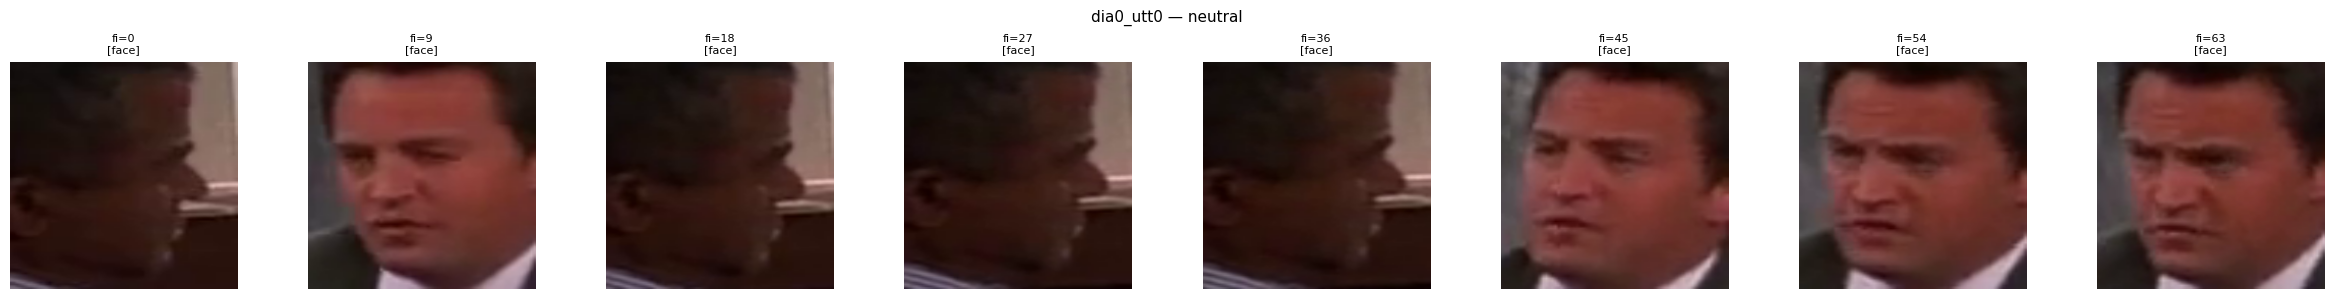

In [16]:
# Show the sampled + cropped frames
n_show = min(8, len(raw_frames))
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1:
    axes = [axes]

for ax, (fi, rgb) in zip(axes, raw_frames[:n_show]):
    box  = get_box_for_frame(fi, box_map, VIDEO_FACE_BOX_MAX_GAP) if VIDEO_CROP_MODE == 'face' else None
    crop = crop_or_resize(rgb, box, VIDEO_IMG_SIZE)
    ax.imshow(crop)
    label = f'fi={fi}' + ('\n[face]' if box else '\n[full]')
    ax.set_title(label, fontsize=8)
    ax.axis('off')

plt.suptitle(f'dia{DEMO_D_ID}_utt{DEMO_U_ID} — {demo_row.emotion_norm}', fontsize=11)
plt.tight_layout()
plt.show()

---
## Full cache build — all splits

Processes **train → dev → test** in sequence.  
Already-written `.npy` files are skipped — the run is fully resumable.

**Optional overrides** — change here without touching `src/config.py`:

In [17]:
# ── Optional parameter overrides ──────────────────────────────────────────────
cache_dir  = VIDEO_CACHE_DIR
crop_mode  = VIDEO_CROP_MODE    # 'face' or 'full'
img_size   = VIDEO_IMG_SIZE
T_cache    = VIDEO_T_CACHE
version    = VERSION
force      = False   # set True to re-build already-cached files
use_gpu    = True    # set False to disable GPU acceleration

print('Running with:')
print(f'  crop_mode={crop_mode}, img_size={img_size}, T_cache={T_cache}')
print(f'  cache_dir={cache_dir}')
print(f'  force={force}, use_gpu={use_gpu}')


Running with:
  crop_mode=face, img_size=224, T_cache=16
  cache_dir=../Data/processed_meld_video/cache
  force=False, use_gpu=True


In [18]:
# ── DEBUG: Check why cache builder filters to 0 utterances ──────────────────
from src.data.video_preprocessing import _LABEL2ID

print("Label map used by build_frame_cache:", _LABEL2ID)

meta = load_video_metadata('train', version=version)
print(f"\nTotal utterances: {len(meta)}")
print(f"Videos exist: {meta['video_exists'].sum()}")
print(f"Emotions in label map: {meta['emotion_norm'].isin(_LABEL2ID).sum()}")

# The filter applied in build_frame_cache
filtered = meta[meta["video_exists"] & meta["emotion_norm"].isin(_LABEL2ID)]
print(f"After filtering (video_exists & emotion in _LABEL2ID): {len(filtered)}")

# Check if there's a mismatch
if len(filtered) == 0:
    print("\n⚠️  PROBLEM: All utterances filtered out!")
    print("Unique emotions in data:", meta['emotion_norm'].unique())
    print("Expected emotions:", list(_LABEL2ID.keys()))


Label map used by build_frame_cache: {'anger': 0, 'disgust': 1, 'fear': 2, 'happiness': 3, 'neutral': 4, 'sadness': 5, 'surprise': 6}

Total utterances: 9989
Videos exist: 9989
Emotions in label map: 9989
After filtering (video_exists & emotion in _LABEL2ID): 9989


In [19]:
cache_out_dirs = {}

for split in ['train', 'dev', 'test']:
    print(f'\n──── {split} ────')
    out = build_frame_cache(
        split     = split,
        version   = version,
        cache_dir = cache_dir,
        crop_mode = crop_mode,
        img_size  = img_size,
        T_cache   = T_cache,
        force     = force,
        use_gpu   = use_gpu,
    )
    cache_out_dirs[split] = out

print('\nCache directories:')
for split, path in cache_out_dirs.items():
    npy_files = [f for f in os.listdir(path) if f.endswith('.npy')] if os.path.isdir(path) else []
    print(f'  [{split:5s}] {len(npy_files)} files → {path}')



──── train ────
[video_cache] Building train frame cache → ../Data/processed_meld_video/cache\npy\v1\train [GPU: ON]
  1 remaining / 9989 total | T=16, size=224, crop=face
  [warn] dia125_utt3: No frames decoded
[video_cache] Done. 0 written, 1 failed.

──── dev ────
[video_cache] dev already fully cached (1108 utterances) → ../Data/processed_meld_video/cache\npy\v1\dev

──── test ────
[video_cache] test already fully cached (2610 utterances) → ../Data/processed_meld_video/cache\npy\v1\test

Cache directories:
  [train] 9988 files → ../Data/processed_meld_video/cache\npy\v1\train
  [dev  ] 1108 files → ../Data/processed_meld_video/cache\npy\v1\dev
  [test ] 2610 files → ../Data/processed_meld_video/cache\npy\v1\test


## Verify a cached clip

Shape : (16, 224, 224, 3)   dtype: uint8
Min / Max pixel : 0 / 229


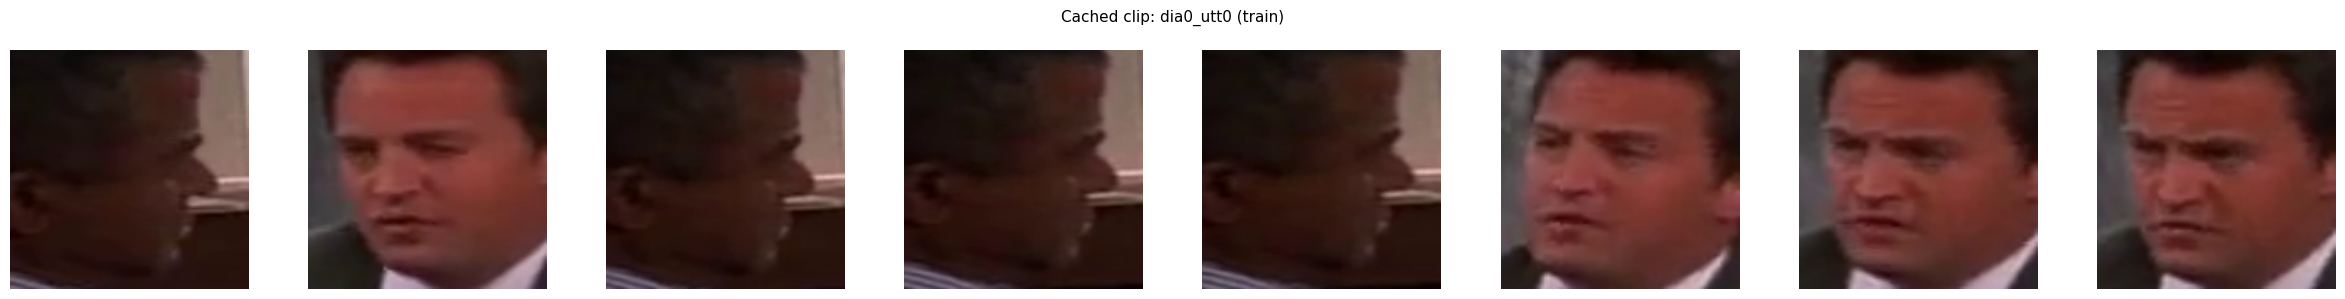

In [20]:
import os

verify_split = 'train'
npy_path = os.path.join(cache_out_dirs[verify_split], f'dia{DEMO_D_ID}_utt{DEMO_U_ID}.npy')

if os.path.exists(npy_path):
    clip = np.load(npy_path)
    print(f'Shape : {clip.shape}   dtype: {clip.dtype}')
    print(f'Min / Max pixel : {clip.min()} / {clip.max()}')

    fig, axes = plt.subplots(1, min(8, clip.shape[0]), figsize=(3 * min(8, clip.shape[0]), 3))
    if clip.shape[0] == 1:
        axes = [axes]
    for ax, frame in zip(axes, clip[:8]):
        ax.imshow(frame)
        ax.axis('off')
    plt.suptitle(f'Cached clip: dia{DEMO_D_ID}_utt{DEMO_U_ID} ({verify_split})', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print(f'File not found: {npy_path}')